In [1]:
!pip install -q pykan

from google.colab import drive
import pandas as pd
import numpy as np
import torch
import gc
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Tesi_CICIoT/train.csv'

# Carichiamo solo le colonne utili castando in float32
df = pd.read_csv(file_path)
label_col = 'label' if 'label' in df.columns else 'Label'

le = LabelEncoder()
df['multiclass_label'] = le.fit_transform(df[label_col])
class_names = le.classes_
num_classes = len(class_names)

# Cap a max 1500 campioni per classe per salvaguardare la RAM
df_sampled = df.groupby('multiclass_label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 1500), random_state=42)
).reset_index(drop=True)

del df
gc.collect()

feature_cols = df_sampled.select_dtypes(include=['float64', 'int64', 'float32', 'int32']).columns.tolist()
feature_cols = [c for c in feature_cols if c not in [label_col, 'binary_label', 'multiclass_label']]

X_raw = df_sampled[feature_cols].values.astype(np.float32)
y = df_sampled['multiclass_label'].values

# Split rigoroso prima dello scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

# Mini-batching tramite DataLoader per velocità e RAM
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Righe totali gestite: {len(df_sampled)} | Dispositivo: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.8 MB/s eta 0:00:00
Mounted at /content/drive


/tmp/ipykernel_4072/837919282.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('multiclass_label', group_keys=False).apply(


Righe totali gestite: 43570 | Dispositivo: cpu


checkpoint directory created: ./model
saving model version 0.0
Avvio addestramento velocizzato...
Epoch [5/30] | Loss Media: 1.1695
Epoch [10/30] | Loss Media: 1.0479
Epoch [15/30] | Loss Media: 0.9856
Epoch [20/30] | Loss Media: 0.9374
Epoch [25/30] | Loss Media: 0.9030
Epoch [30/30] | Loss Media: 0.8772

Accuracy Multiclasse: 0.7081
Macro F1-Score:       0.6337


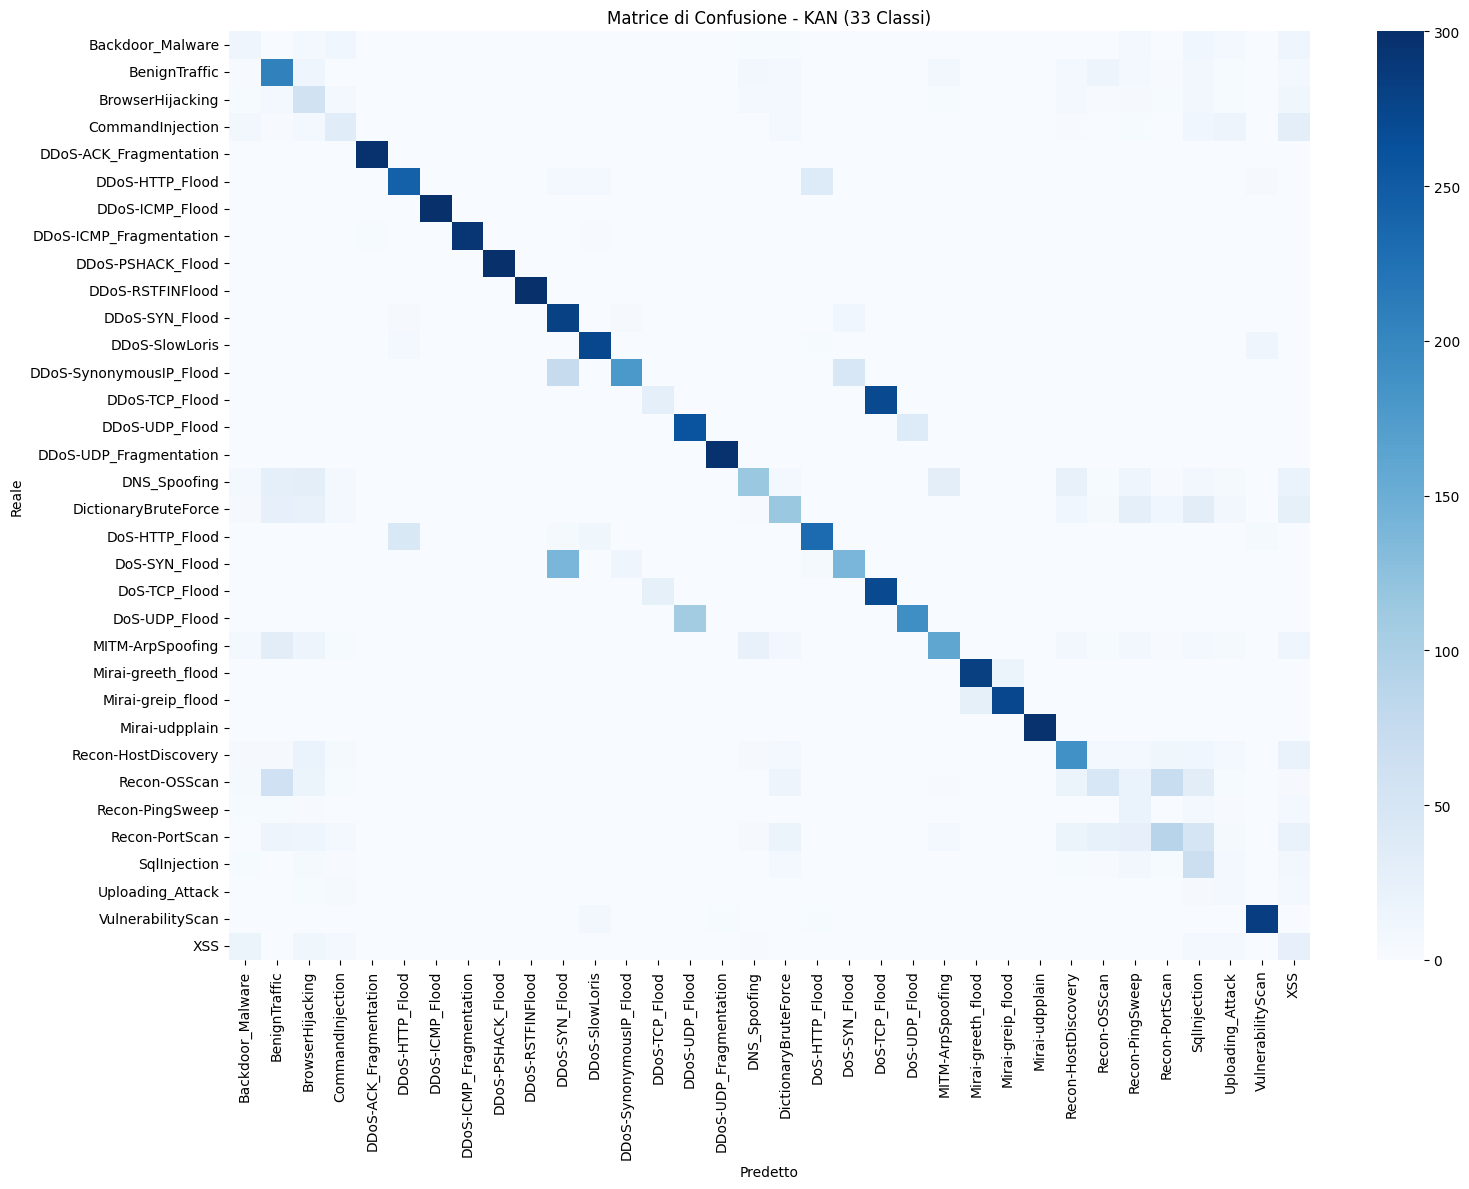

In [2]:
from kan import KAN
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

input_dim = X_train.shape[1]
model = KAN(width=[input_dim, 32, num_classes], grid=3, k=3, seed=42).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

epochs = 30
print("Avvio addestramento velocizzato...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        out = model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss Media: {total_loss / len(train_loader):.4f}")

# Valutazione
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test).to(device)
    preds = torch.argmax(model(X_test_tensor), dim=1).cpu().numpy()

acc = accuracy_score(y_test, preds)
_, _, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)

print(f"\nAccuracy Multiclasse: {acc:.4f}")
print(f"Macro F1-Score:       {macro_f1:.4f}")

# Matrice di Confusione
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice di Confusione - KAN (33 Classi)")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [3]:
from kan import KAN
from sklearn.utils.class_weight import compute_class_weight

print("Inizializzazione KAN Multiclasse...")
input_dim = X_train.shape[1]

# KAN: Input (46) -> Hidden (64) -> Output (33)
model = KAN(width=[input_dim, 64, num_classes], grid=5, k=3, seed=42).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Pesi per bilanciare le 33 classi nella CrossEntropyLoss
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

epochs = 20
print(f"Avvio addestramento su {epochs} epoche con Mini-Batch...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss Media: {epoch_loss:.4f}")

Inizializzazione KAN Multiclasse...
checkpoint directory created: ./model
saving model version 0.0
Avvio addestramento su 20 epoche con Mini-Batch...
Epoch [5/20] | Loss Media: 1.4539
Epoch [10/20] | Loss Media: 1.1384
Epoch [15/20] | Loss Media: 1.0452
Epoch [20/20] | Loss Media: 0.9853


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

print("\n--- VALUTAZIONE MULTICLASSE (33 CLASSI) ---")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metriche Richieste
acc = accuracy_score(all_labels, all_preds)
_, _, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

print(f"Accuracy Multiclasse: {acc:.4f}")
print(f"Macro F1-Score:       {macro_f1:.4f}")

# Matrice di Confusione
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matrice di Confusione - KAN 33 Classi", fontsize=14)
plt.xlabel("Classe Predetta", fontsize=12)
plt.ylabel("Classe Reale", fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix_kan.png", dpi=300)
plt.show()


--- VALUTAZIONE MULTICLASSE (33 CLASSI) ---


NameError: name 'test_loader' is not defined